In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import linregress, t

from pneumococcus_data import data_observation

In [2]:
from sklearn.metrics import r2_score 

In [3]:
Iran, Denmark, Brazil, Nepal, Mozambique = data_observation()

In [7]:
country_strain = np.array([[np.array(Iran.strain), np.array(Denmark.strain)], [np.array(Brazil.strain), np.array(Mozambique.strain)]], dtype = object)
country_cases = np.array([[np.array(Iran.cases), np.array(Denmark.cases)], [np.array(Brazil.cases), np.array(Mozambique.cases)]], dtype = object)

Nepal_cases = np.array(Nepal.cases)
Nepal_strain = np.array(Nepal.strain)

slope, intercept, r, p, std_err, intercept_stderr
Nepal vs Iran: 0.442872645290245| 0.583879247289719| 0.4455181625441254| 0.08372869846496594| 0.23785093534407756
r_squared value: 0.19848643315669312
p-value intercept: 0.030993455010711095
------------------------------------------------------------------------------------
Nepal vs Denmark: 1.3166541840961035| -0.31047251572434975| 0.5990675722620133| 0.0007560262769416056| 0.345126444922369
r_squared value: 0.3588819561359031
p-value intercept: 0.38635023746215114
------------------------------------------------------------------------------------
Nepal vs Brazil: 1.6669844639013587| -0.6603363828336679| 0.6790013456014691| 0.00036741335153723506| 0.39330403141560843
r_squared value: 0.46104282732860546
p-value intercept: 0.11549852188296605
------------------------------------------------------------------------------------
Nepal vs Mozambique: 0.6435897826159013| 0.3714007549825722| 0.4124928559276785| 0.0090662532314386| 0.2336638

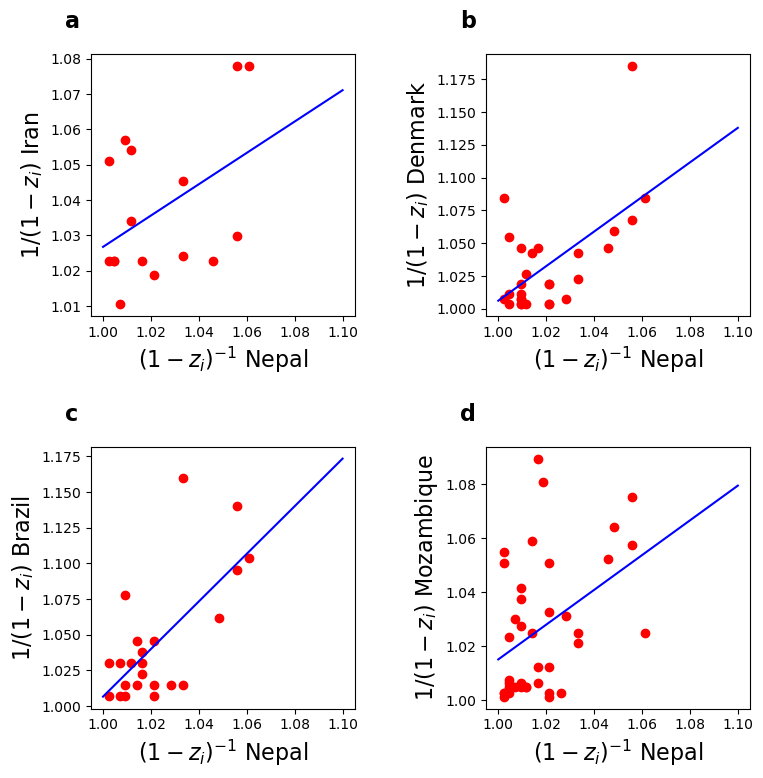

In [9]:
label = np.array([['Iran', 'Denmark'], ['Brazil', 'Mozambique']])
order = np.array([['a', 'b'], ['c', 'd']])

print('slope, intercept, r, p, std_err, intercept_stderr')

fig, ax = plt.subplots(2, 2, figsize = (8.5, 8.5))
fig.subplots_adjust(hspace = 0.5, wspace = 0.5)
x = np.linspace(1, 1.1, 50)


for i in range (0, 2):
    for j in range (0, 2):
        
        pair = [Nepal_strain, country_strain[i,j]]
        common_set = list(set.intersection(*map(set, pair)))
        
        Nepal_common = []
        second_common = []
        
        cases = country_cases[i,j]
        strains = country_strain[i,j]
        
        for strain in common_set:
            index_Nepal = np.where(Nepal_strain == strain) #find the index of common strain
            index_Nepal = index_Nepal[0]
            Nepal_common.extend(1/(1 - Nepal_cases[index_Nepal]))
            
            index_second = np.where(strains == strain) #find the index of common strain
            index_second = index_second[0]
            second_common.extend(1/(1 - cases[index_second]))
        
        Nepal_common = np.array(Nepal_common)
        second_common = np.array(second_common)
        slope, intercept, r, p, std_err = stats.linregress(Nepal_common, second_common)
        
        #test null hypothesis intercept
        yhat = intercept + slope * Nepal_common
        n = Nepal_common.size
        sse = np.sum((second_common - yhat)**2)
        s   = np.sqrt(sse / (n - 2))
        Sxx = np.sum((Nepal_common - Nepal_common.mean())**2)

        intercept_stderr = s * np.sqrt(1/n + (Nepal_common.mean()**2)/Sxx)
        #print("intercept_stderr =", intercept_stderr)
        
        df  = len(Nepal_common) - 2        # n - 2 d.f.
        t_stat = intercept /intercept_stderr
        p_intercept = 2 * t.sf(abs(t_stat), df)   # H0: intercept = 0
        #print("p-value intercept =", p_intercept)
        
        ax[i,j].scatter(Nepal_common, second_common, color = 'red')
        ax[i,j].plot(x, slope*x + intercept, color = 'blue')
        ax[i,j].set_xlabel('$(1-z_i)^{-1}$ Nepal', fontsize = 16)
        ax[i,j].set_ylabel('$1/(1-z_i)$ {}'.format(label[i,j]), fontsize = 16)
        ax[i,j].text(-.1, 1.1, '{}'.format(order[i,j]), transform=ax[i,j].transAxes, size=16, weight='bold')
        
        print('Nepal vs {}: '.format(label[i,j])  +str(slope) + '| ' + str(intercept) + '| ' 
                                                  + str(r) + '| ' + str(p) + '| ' + str(std_err))
        
        model = Nepal_common*slope + intercept
        r_squared = r2_score(second_common, model)
        print( 'r_squared value: '+ str(r_squared))
        print( 'p-value intercept: '+ str(p_intercept))
        print('------------------------------------------------------------------------------------')
plt.show()

slope, intercept, r, p, std_err
Denmark vs Mozambique: 0.35915829224020873| 0.6568507039754528| 0.5667170137571939| 0.0031396647576558065| 0.10887717067253712
r_squared value: 0.3211681736818718
p-value intercept: 6.241943357422171e-06
------------------------------------------------------------------------------------
Denmark vs Brazil: 0.500338143185377| 0.5330288969679753| 0.49403604400563855| 0.05176808045570739| 0.23533216299324086
r_squared value: 0.24407161277673972
p-value intercept: 0.04792555593262456
------------------------------------------------------------------------------------
Mozambique vs Brazil: 0.4800791308468256| 0.5520748575311025| 0.2731138514581231| 0.23096856889273212| 0.3879351380035875
r_squared value: 0.07459117585828978
p-value intercept: 0.1843142858718692
------------------------------------------------------------------------------------


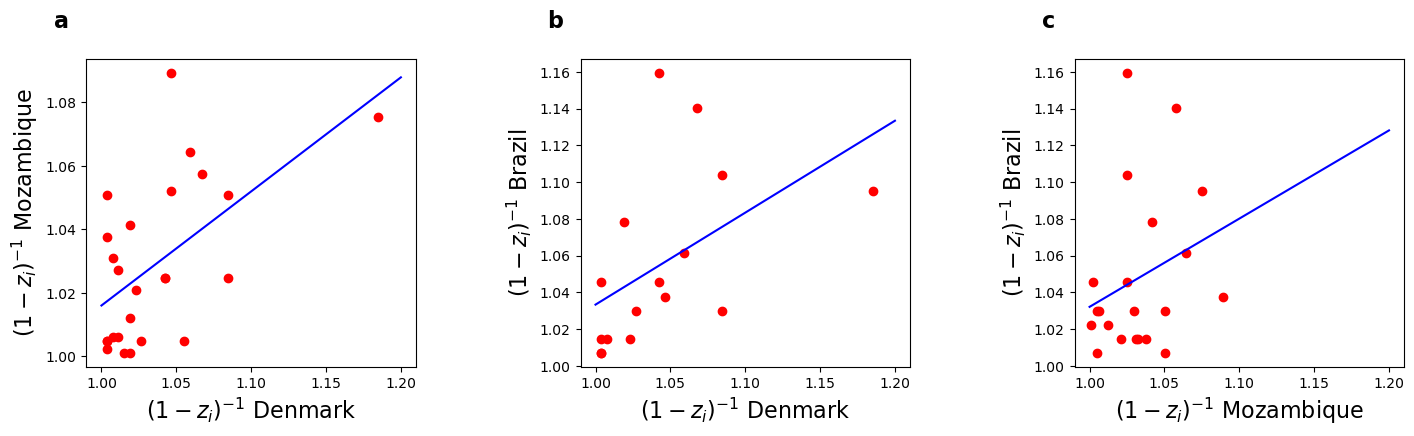

In [11]:
label = np.array(['Denmark', 'Brazil', 'Mozambique'])
order = np.array(['a', 'b', 'c'])
sub_country_strain = np.array([np.array(Denmark.strain), np.array(Brazil.strain), np.array(Mozambique.strain)], dtype = object)
sub_country_cases = np.array([np.array(Denmark.cases), np.array(Brazil.cases), np.array(Mozambique.cases)], dtype = object)


print('slope, intercept, r, p, std_err')

fig, ax = plt.subplots(1, 3, figsize = (17, 4))
fig.subplots_adjust( wspace = 0.5)
x = np.linspace(1, 1.2, 50)


for i in range (0, 3):
    
        s1_strain = sub_country_strain[i]
        s2_strain = sub_country_strain[i-1]
        
        s1_cases = sub_country_cases[i]
        s2_cases = sub_country_cases[i-1]
        
        pair = [s1_strain, s2_strain]
        common_set = list(set.intersection(*map(set, pair)))
        
        s1_common = []
        s2_common = []
                
        for strain in common_set:
            index_s1 = np.where(s1_strain == strain) #find the index of common strain
            index_s1 = index_s1[0]
            s1_common.extend(1/(1 - s1_cases[index_s1]))
            
            index_s2 = np.where(s2_strain == strain) #find the index of common strain
            index_s2 = index_s2[0]
            s2_common.extend(1/(1 - s2_cases[index_s2]))
        
        s1_common = np.array(s1_common)
        s2_common = np.array(s2_common)
        
        #swap the 2 axis in second figure
        if i == 1:
            temp = s1_common
            s1_common = s2_common
            s2_common = temp
            
        slope, intercept, r, p, std_err = stats.linregress(s1_common, s2_common)
        
        #test null hypothesis intercept
        yhat = intercept + slope * s1_common
        n = s1_common.size
        sse = np.sum((s2_common - yhat)**2)
        s   = np.sqrt(sse / (n - 2))
        Sxx = np.sum((s1_common - s1_common.mean())**2)

        intercept_stderr = s * np.sqrt(1/n + (s1_common.mean()**2)/Sxx)
        #print("intercept_stderr =", intercept_stderr)
        
        df  = len(s1_common) - 2        # n - 2 d.f.
        t_stat = intercept /intercept_stderr
        p_intercept = 2 * t.sf(abs(t_stat), df)   # H0: intercept = 0

        ax[i].scatter(s1_common, s2_common, color = 'red')
        ax[i].plot(x, slope*x + intercept, color = 'blue')
        if i == 1:
            ax[i].set_xlabel('$(1-z_i)^{{-1}}$ {}'.format(label[i-1]), fontsize = 16)
            ax[i].set_ylabel('$(1-z_i)^{{-1}}$ {}'.format(label[i]), fontsize = 16)
            ax[i].text(-.1, 1.1, '{}'.format(order[i]), transform=ax[i].transAxes, size=16, weight='bold')
        
            print('{} vs {}: '.format(label[i-1],label[i])  +str(slope) + '| ' + str(intercept) 
                                                            + '| ' + str(r) + '| ' + str(p) + '| ' + str(std_err))

        else:
            ax[i].set_xlabel('$(1-z_i)^{{-1}}$ {}'.format(label[i]), fontsize = 16)
            ax[i].set_ylabel('$(1-z_i)^{{-1}}$ {}'.format(label[i-1]), fontsize = 16)
            ax[i].text(-.1, 1.1, '{}'.format(order[i]), transform=ax[i].transAxes, size=16, weight='bold')
        
            print('{} vs {}: '.format(label[i],label[i-1])  +str(slope) + '| ' + str(intercept) 
                                                            + '| ' + str(r) + '| ' + str(p) + '| ' + str(std_err))
        
        model = s1_common*slope + intercept
        r_squared = r2_score(s2_common, model)
        print( 'r_squared value: '+ str(r_squared))
        print( 'p-value intercept: '+ str(p_intercept))
        print('------------------------------------------------------------------------------------')
        
plt.show()